<a href="https://colab.research.google.com/github/ManuelRomero2025/CienciasdeDatos1/blob/main/V1_diabetes_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab experto: Ciencia de Datos en salud para diabetes

Este notebook usa la base `diabetes.csv` cargada por el usuario y desarrolla un flujo completo de **Ciencia de Datos aplicada a salud**.

## Objetivo

Descubrir insights ocultos relacionados con diabetes mediante:

- diagnóstico y limpieza clínica de datos;
- ingeniería de variables;
- análisis exploratorio;
- PCA;
- clustering;
- SMOTE;
- validación cruzada;
- modelos predictivos;
- importancia de variables;
- SHAP Values;
- bootstrap clínico;
- interpretación académica y clínica.

## Variable objetivo

- `Outcome = 0`: paciente sin diabetes.
- `Outcome = 1`: paciente con diabetes.

## Insight oculto esperado

La glucosa suele aparecer como predictor dominante, pero el riesgo real de diabetes puede depender de perfiles multivariados: glucosa, IMC, edad, insulina, embarazos y función hereditaria.

In [8]:
# ============================================================
# 0. Instalación de librerías adicionales
# ============================================================

!pip -q install imbalanced-learn shap

In [9]:
# ============================================================
# 1. Librerías
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, silhouette_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import statsmodels.formula.api as smf

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print("SHAP no pudo importarse:", e)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 123

# 1. Carga y diagnóstico inicial

Se revisan dimensiones, tipos de datos, valores nulos y distribución de la variable objetivo.

In [10]:
# Asegúrate de haber montado Google Drive previamente
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# ============================================================
# 2. Cargar datos
# ============================================================

df = pd.read_csv('/content/drive/MyDrive/CienciasDatos2025/PCA2026/diabetes.csv')

print("Dimensiones:", df.shape)
display(df.head())

Dimensiones: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1


Columnas:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Tipos de datos:


,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Valores nulos explícitos:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0



Resumen estadístico:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0000,3.8451,3.3696,0.0000,1.0000,3.0000,6.0000,17.0000
Glucose,768.0000,120.8945,31.9726,0.0000,99.0000,117.0000,140.2500,199.0000
BloodPressure,768.0000,69.1055,19.3558,0.0000,62.0000,72.0000,80.0000,122.0000
SkinThickness,768.0000,20.5365,15.9522,0.0000,0.0000,23.0000,32.0000,99.0000
Insulin,768.0000,79.7995,115.2440,0.0000,0.0000,30.5000,127.2500,846.0000
BMI,768.0000,31.9926,7.8842,0.0000,27.3000,32.0000,36.6000,67.1000
DiabetesPedigreeFunction,768.0000,0.4719,0.3313,0.0780,0.2437,0.3725,0.6262,2.4200
Age,768.0000,33.2409,11.7602,21.0000,24.0000,29.0000,41.0000,81.0000
Outcome,768.0000,0.3490,0.4770,0.0000,0.0000,0.0000,1.0000,1.0000



Distribución de Outcome:


,count
Outcome,
0,500
1,268


,proportion
Outcome,
0,65.1000
1,34.9000


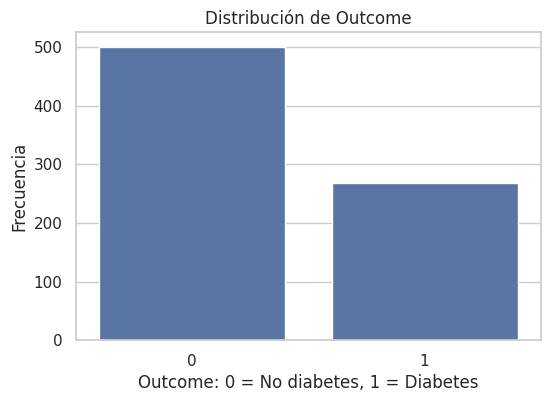

In [12]:
# ============================================================
# 3. Diagnóstico inicial
# ============================================================

print("Columnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos explícitos:")
display(df.isna().sum())

print("\nResumen estadístico:")
display(df.describe().T)

print("\nDistribución de Outcome:")
display(df["Outcome"].value_counts())
display((df["Outcome"].value_counts(normalize=True)*100).round(2))

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Outcome")
plt.title("Distribución de Outcome")
plt.xlabel("Outcome: 0 = No diabetes, 1 = Diabetes")
plt.ylabel("Frecuencia")
plt.show()

# 2. Limpieza clínica

En esta base, algunas variables pueden tener valor cero aunque clínicamente no sea razonable. Se tratan como faltantes codificados:

- `Glucose`
- `BloodPressure`
- `SkinThickness`
- `Insulin`
- `BMI`

Se reemplazan por `NaN` y se imputan con la mediana.

,Variable,Ceros,Porcentaje_ceros
0,Glucose,5,0.6500
1,BloodPressure,35,4.5600
2,SkinThickness,227,29.5600
3,Insulin,374,48.7000
4,BMI,11,1.4300


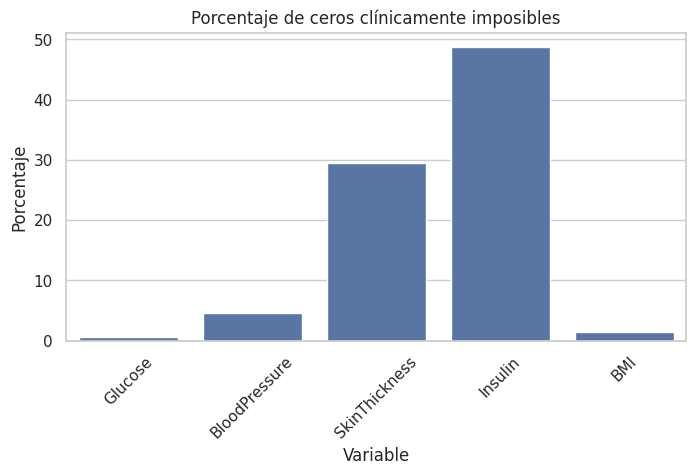

In [13]:
# ============================================================
# 4. Ceros clínicamente imposibles
# ============================================================

clinical_zero_vars = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_summary = pd.DataFrame({
    "Variable": clinical_zero_vars,
    "Ceros": [int((df[v] == 0).sum()) for v in clinical_zero_vars],
    "Porcentaje_ceros": [round((df[v] == 0).mean() * 100, 2) for v in clinical_zero_vars]
})

display(zero_summary)

plt.figure(figsize=(8,4))
sns.barplot(data=zero_summary, x="Variable", y="Porcentaje_ceros")
plt.title("Porcentaje de ceros clínicamente imposibles")
plt.ylabel("Porcentaje")
plt.xticks(rotation=45)
plt.show()

In [14]:
# ============================================================
# 5. Imputación por mediana
# ============================================================

df_clean = df.copy()
for var in clinical_zero_vars:
    df_clean[var] = df_clean[var].replace(0, np.nan)

print("Nulos tras reemplazar ceros:")
display(df_clean.isna().sum())

imputation_table = []
for var in clinical_zero_vars:
    med = df_clean[var].median()
    df_clean[var] = df_clean[var].fillna(med)
    imputation_table.append({"Variable": var, "Mediana_imputada": med})

display(pd.DataFrame(imputation_table))

print("Nulos después de imputar:")
display(df_clean.isna().sum())

Nulos tras reemplazar ceros:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


,Variable,Mediana_imputada
0,Glucose,117.0000
1,BloodPressure,72.0000
2,SkinThickness,29.0000
3,Insulin,125.0000
4,BMI,32.3000


Nulos después de imputar:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


# 3. Ingeniería de variables clínicas

Se crean grupos clínicos para facilitar el análisis segmentado y descubrir patrones ocultos.

In [15]:
# ============================================================
# 6. Feature engineering clínico
# ============================================================

df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[20, 30, 40, 50, 90],
    labels=["21-30", "31-40", "41-50", "51+"],
    include_lowest=True
)

df_clean["BMIGroup"] = pd.cut(
    df_clean["BMI"],
    bins=[0, 25, 30, 35, 100],
    labels=["Normal/Low", "Overweight", "Obesity I", "Obesity II+"],
    include_lowest=True
)

df_clean["GlucoseGroup"] = pd.cut(
    df_clean["Glucose"],
    bins=[0, 100, 125, 300],
    labels=["Normal", "Prediabetes range", "High"],
    include_lowest=True
)

df_clean["PedigreeGroup"] = pd.qcut(
    df_clean["DiabetesPedigreeFunction"],
    q=3,
    labels=["Low hereditary risk", "Medium hereditary risk", "High hereditary risk"]
)

for col in ["AgeGroup", "BMIGroup", "GlucoseGroup", "PedigreeGroup"]:
    print(f"\nDistribución de {col}:")
    display(df_clean[col].value_counts())

display(df_clean.head())


Distribución de AgeGroup:


,count
AgeGroup,
21-30,417
31-40,157
41-50,113
51+,81



Distribución de BMIGroup:


,count
BMIGroup,
Obesity II+,244
Obesity I,232
Overweight,180
Normal/Low,112



Distribución de GlucoseGroup:


,count
GlucoseGroup,
High,297
Prediabetes range,262
Normal,209



Distribución de PedigreeGroup:


,count
PedigreeGroup,
Low hereditary risk,258
High hereditary risk,256
Medium hereditary risk,254


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,AgeGroup,BMIGroup,GlucoseGroup,PedigreeGroup
0,6,148.0000,72.0000,35.0000,125.0000,33.6000,0.6270,50,1,41-50,Obesity I,High,High hereditary risk
1,1,85.0000,66.0000,29.0000,125.0000,26.6000,0.3510,31,0,31-40,Overweight,Normal,Medium hereditary risk
2,8,183.0000,64.0000,29.0000,125.0000,23.3000,0.6720,32,1,31-40,Normal/Low,High,High hereditary risk
3,1,89.0000,66.0000,23.0000,94.0000,28.1000,0.1670,21,0,21-30,Overweight,Normal,Low hereditary risk
4,0,137.0000,40.0000,35.0000,168.0000,43.1000,2.2880,33,1,31-40,Obesity II+,High,High hereditary risk


# 4. Análisis exploratorio

Se comparan las variables clínicas entre pacientes con y sin diabetes.

In [16]:
# ============================================================
# 7. Resumen descriptivo por Outcome
# ============================================================

numeric_vars = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"
]

summary_outcome = df_clean.groupby("Outcome").agg(
    n=("Outcome", "size"),
    Glucose_mean=("Glucose", "mean"),
    Glucose_median=("Glucose", "median"),
    BMI_mean=("BMI", "mean"),
    BMI_median=("BMI", "median"),
    Age_mean=("Age", "mean"),
    Age_median=("Age", "median"),
    Insulin_median=("Insulin", "median"),
    Pedigree_mean=("DiabetesPedigreeFunction", "mean")
).round(3)

display(summary_outcome)

,n,Glucose_mean,Glucose_median,BMI_mean,BMI_median,Age_mean,Age_median,Insulin_median,Pedigree_mean
Outcome,,,,,,,,,
0,500,110.6820,107.5000,30.8860,30.4000,31.1900,27.0000,125.0000,0.4300
1,268,142.1310,140.0000,35.3840,34.2500,37.0670,36.0000,125.0000,0.5500


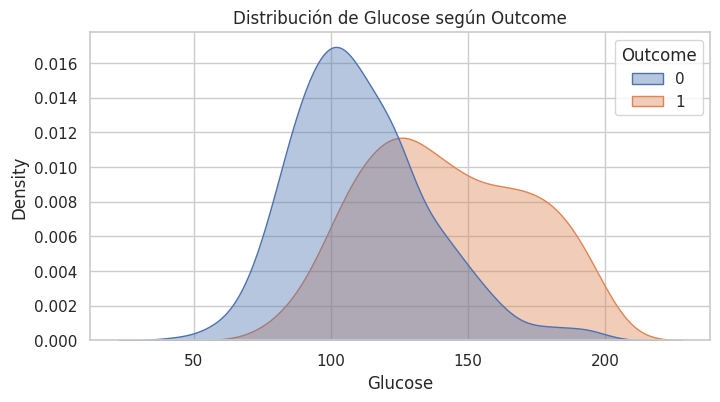

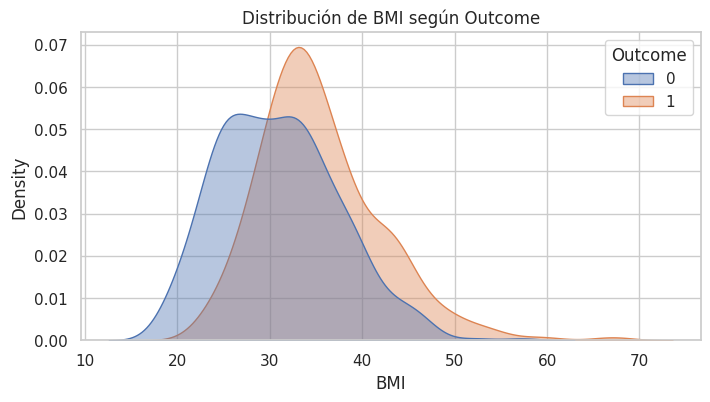

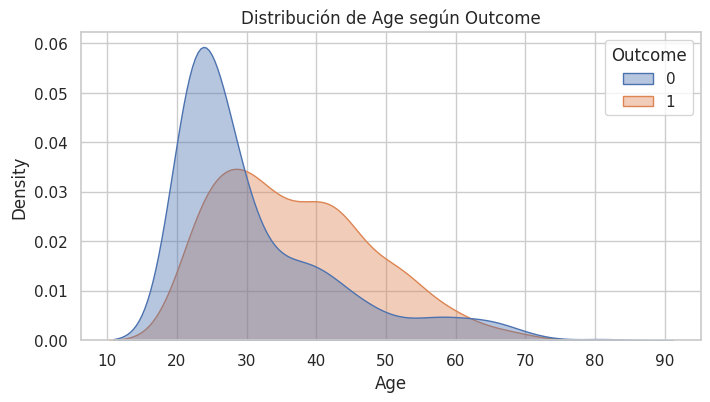

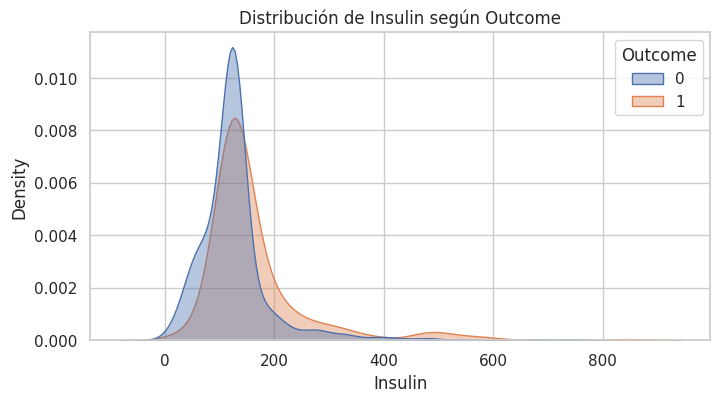

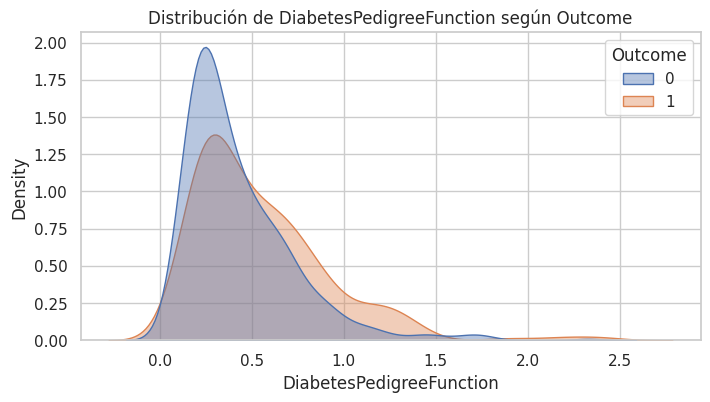

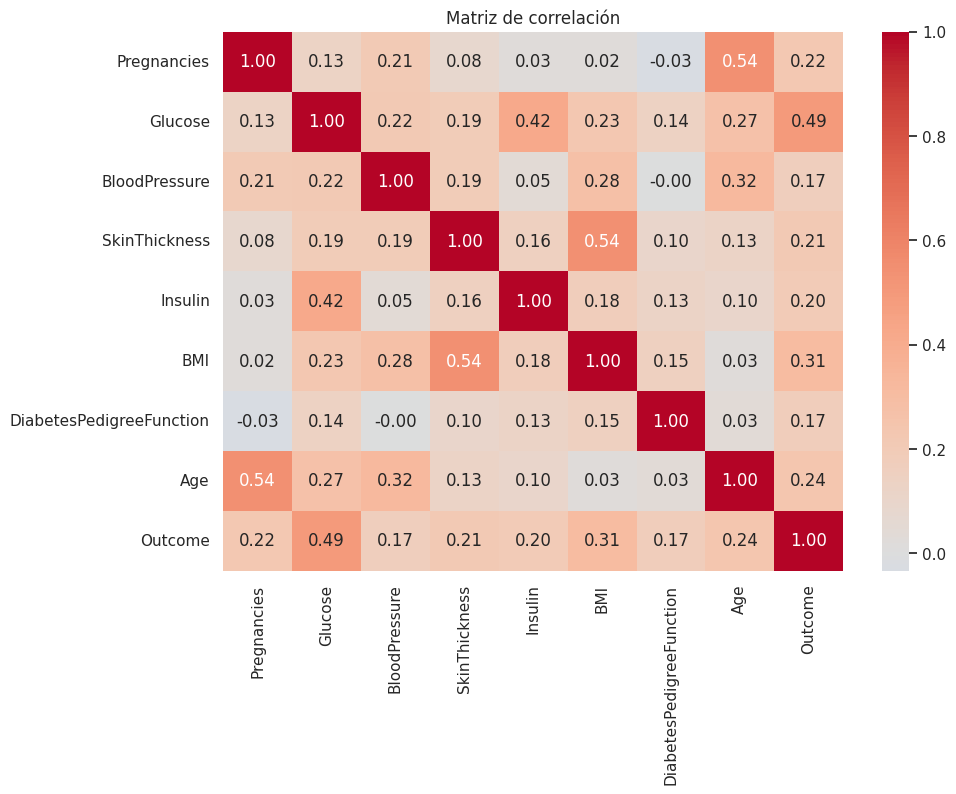

In [17]:
# ============================================================
# 8. Gráficos exploratorios
# ============================================================

for var in ["Glucose", "BMI", "Age", "Insulin", "DiabetesPedigreeFunction"]:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=df_clean, x=var, hue="Outcome", fill=True, common_norm=False, alpha=0.4)
    plt.title(f"Distribución de {var} según Outcome")
    plt.show()

plt.figure(figsize=(10,7))
corr = df_clean[numeric_vars + ["Outcome"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

# 5. Insight superficial vs. insight oculto

Primero se muestra el patrón general por glucosa. Luego se segmenta por edad, IMC y riesgo hereditario para detectar patrones más profundos.

,GlucoseGroup,count,mean,DiabetesRate
0,Normal,209,0.0861,8.6124
1,Prediabetes range,262,0.2824,28.2443
2,High,297,0.5926,59.2593


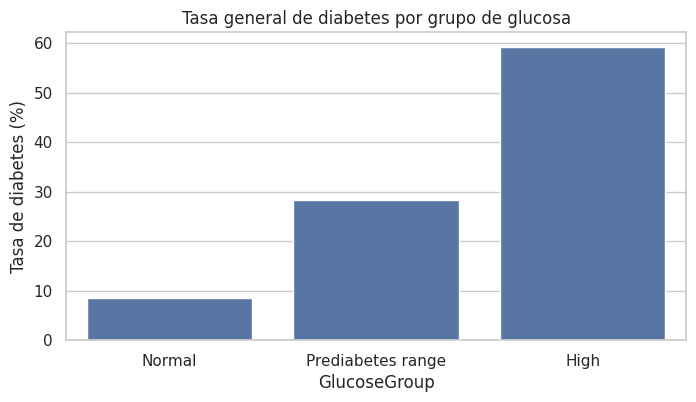

In [18]:
# ============================================================
# 9. Tasa general por glucosa
# ============================================================

overall_glucose = (
    df_clean.groupby("GlucoseGroup")["Outcome"]
    .agg(["count", "mean"])
    .reset_index()
)
overall_glucose["DiabetesRate"] = overall_glucose["mean"] * 100

display(overall_glucose)

plt.figure(figsize=(8,4))
sns.barplot(data=overall_glucose, x="GlucoseGroup", y="DiabetesRate")
plt.title("Tasa general de diabetes por grupo de glucosa")
plt.ylabel("Tasa de diabetes (%)")
plt.show()

,AgeGroup,GlucoseGroup,count,mean,DiabetesRate
0,21-30,Normal,143,0.0490,4.8951
1,21-30,Prediabetes range,153,0.1634,16.3399
2,21-30,High,121,0.4793,47.9339
3,31-40,Normal,33,0.1212,12.1212
4,31-40,Prediabetes range,54,0.4630,46.2963
5,31-40,High,70,0.6714,67.1429
6,41-50,Normal,26,0.1923,19.2308
7,41-50,Prediabetes range,33,0.5152,51.5152
8,41-50,High,54,0.7778,77.7778
9,51+,Normal,7,0.2857,28.5714


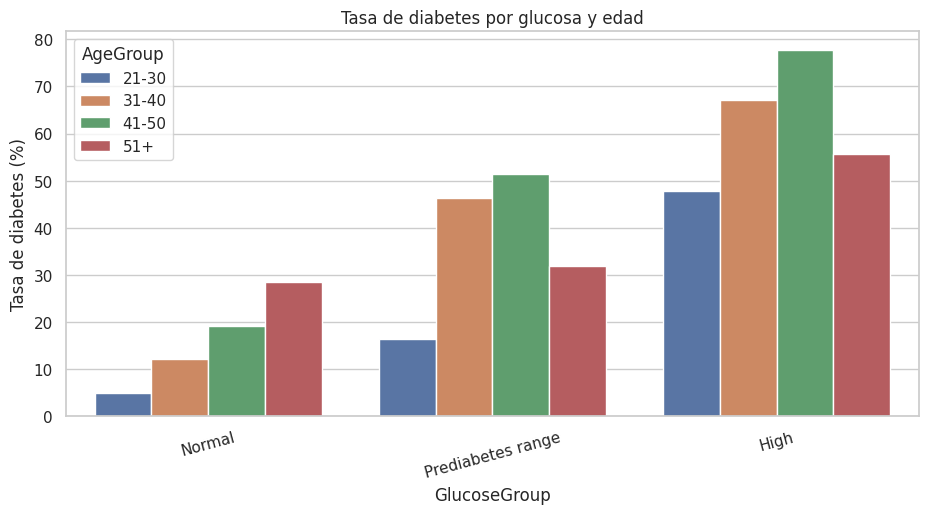

,BMIGroup,GlucoseGroup,count,mean,DiabetesRate
0,Normal/Low,Normal,48,0.0000,0.0000
1,Normal/Low,Prediabetes range,44,0.0227,2.2727
2,Normal/Low,High,20,0.3000,30.0000
3,Overweight,Normal,52,0.0769,7.6923
4,Overweight,Prediabetes range,66,0.3030,30.3030
5,Overweight,High,62,0.3226,32.2581
6,Obesity I,Normal,55,0.1091,10.9091
7,Obesity I,Prediabetes range,80,0.3875,38.7500
8,Obesity I,High,97,0.6701,67.0103
9,Obesity II+,Normal,54,0.1481,14.8148


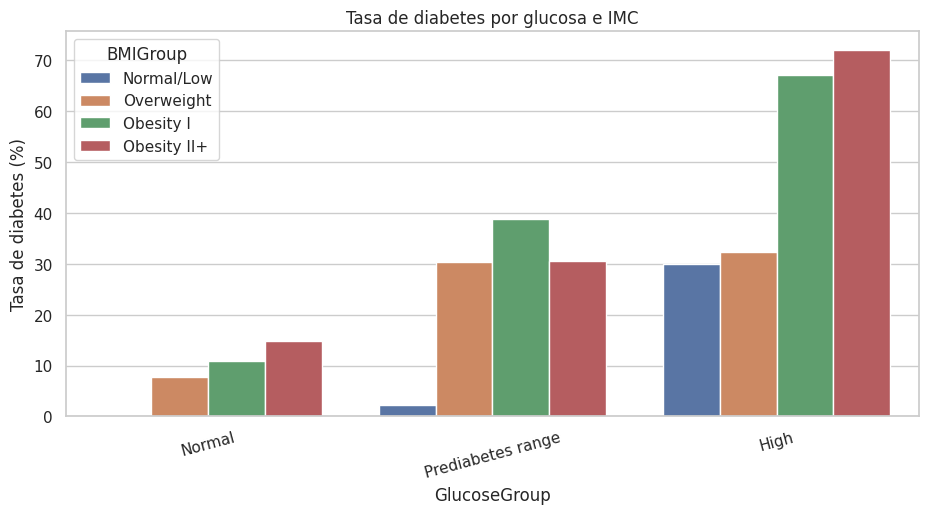

,PedigreeGroup,GlucoseGroup,count,mean,DiabetesRate
0,Low hereditary risk,Normal,64,0.0625,6.2500
1,Low hereditary risk,Prediabetes range,110,0.2364,23.6364
2,Low hereditary risk,High,84,0.4881,48.8095
3,Medium hereditary risk,Normal,83,0.0723,7.2289
4,Medium hereditary risk,Prediabetes range,76,0.2105,21.0526
5,Medium hereditary risk,High,95,0.6000,60.0000
6,High hereditary risk,Normal,62,0.1290,12.9032
7,High hereditary risk,Prediabetes range,76,0.4211,42.1053
8,High hereditary risk,High,118,0.6610,66.1017


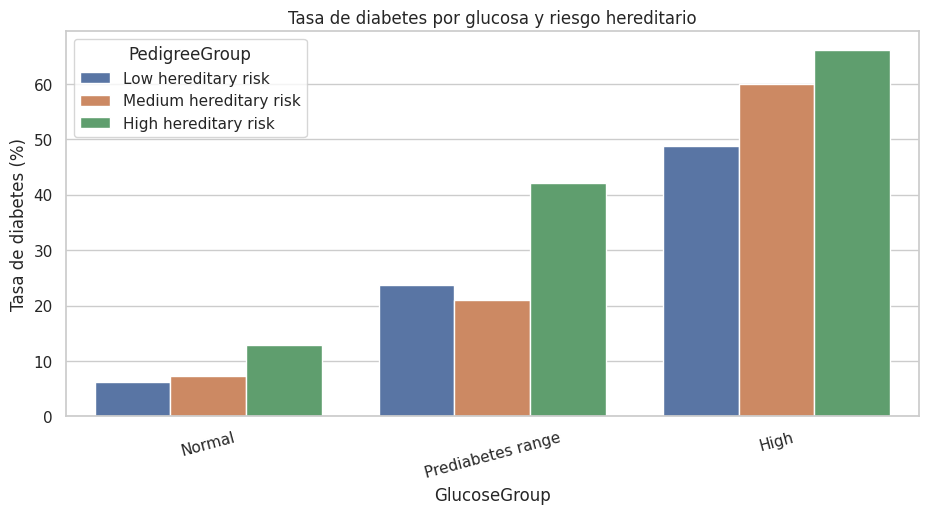

In [19]:
# ============================================================
# 10. Análisis segmentado
# ============================================================

def segmented_rate(data, segment_var, clinical_var):
    table = (
        data.groupby([segment_var, clinical_var])["Outcome"]
        .agg(["count", "mean"])
        .reset_index()
    )
    table["DiabetesRate"] = table["mean"] * 100
    return table

segments = [
    ("AgeGroup", "GlucoseGroup", "Tasa de diabetes por glucosa y edad"),
    ("BMIGroup", "GlucoseGroup", "Tasa de diabetes por glucosa e IMC"),
    ("PedigreeGroup", "GlucoseGroup", "Tasa de diabetes por glucosa y riesgo hereditario")
]

for seg, clin, title in segments:
    table = segmented_rate(df_clean, seg, clin)
    display(table)
    plt.figure(figsize=(11,5))
    sns.barplot(data=table, x=clin, y="DiabetesRate", hue=seg)
    plt.title(title)
    plt.ylabel("Tasa de diabetes (%)")
    plt.xticks(rotation=15)
    plt.show()

# 6. Pruebas de hipótesis

Se aplica prueba t de Welch para comparar promedios entre pacientes con y sin diabetes.

In [20]:
# ============================================================
# 11. Pruebas t de Welch
# ============================================================

test_results = []
for var in numeric_vars:
    g0 = df_clean.loc[df_clean["Outcome"] == 0, var]
    g1 = df_clean.loc[df_clean["Outcome"] == 1, var]
    t_stat, p_value = stats.ttest_ind(g0, g1, equal_var=False)
    test_results.append({
        "Variable": var,
        "Media_No_Diabetes": g0.mean(),
        "Media_Diabetes": g1.mean(),
        "Diferencia_medias": g1.mean() - g0.mean(),
        "t_stat": t_stat,
        "p_value": p_value
    })

test_results_df = pd.DataFrame(test_results).round(5)
display(test_results_df.sort_values("p_value"))

,Variable,Media_No_Diabetes,Media_Diabetes,Diferencia_medias,t_stat,p_value
0,Pregnancies,3.2980,4.8657,1.5677,-5.9070,0.0000
1,Glucose,110.6820,142.1306,31.4486,-14.8527,0.0000
2,BloodPressure,70.9200,75.1231,4.2031,-4.6483,0.0000
3,SkinThickness,27.7260,31.6866,3.9606,-6.0657,0.0000
4,Insulin,127.7920,164.7015,36.9095,-5.2676,0.0000
5,BMI,30.8856,35.3836,4.4980,-9.0518,0.0000
7,Age,31.1900,37.0672,5.8772,-6.9207,0.0000
6,DiabetesPedigreeFunction,0.4297,0.5505,0.1208,-4.5768,0.0000


# 7. PCA: Análisis de Componentes Principales

El PCA permite visualizar la estructura multivariada de los pacientes y evaluar si hay separación parcial entre pacientes con y sin diabetes.

,Componente,Varianza_Explicada,Varianza_Acumulada
0,PC1,0.2854,0.2854
1,PC2,0.1869,0.4723
2,PC3,0.1427,0.6150
3,PC4,0.1146,0.7296
4,PC5,0.0961,0.8257
5,PC6,0.0679,0.8936
6,PC7,0.0586,0.9521
7,PC8,0.0479,1.0000


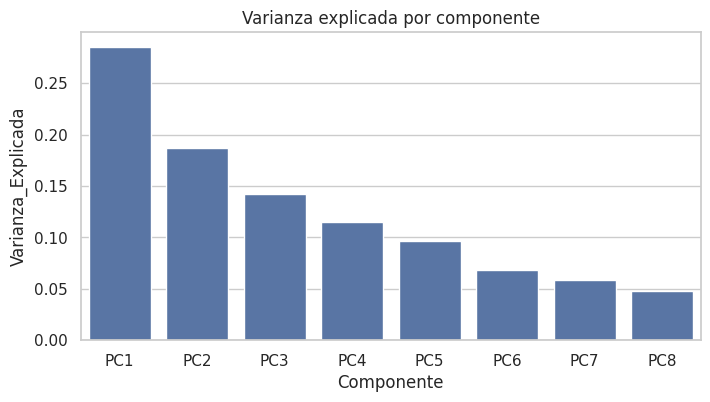

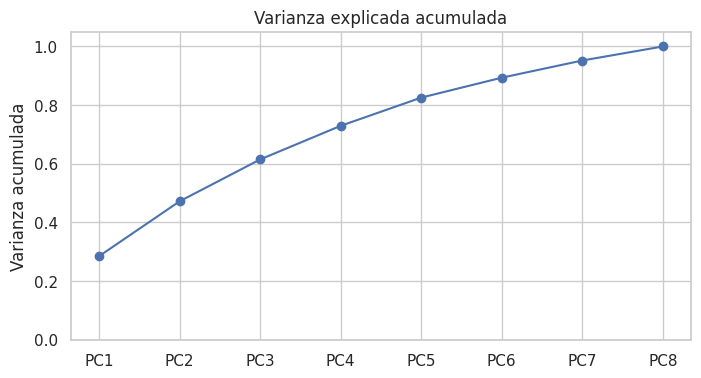

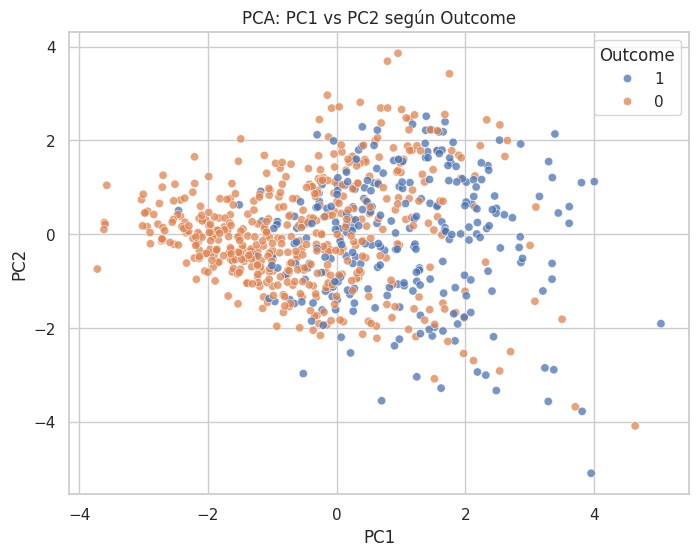

In [21]:
# ============================================================
# 12. PCA
# ============================================================

X = df_clean[numeric_vars]
y = df_clean["Outcome"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "Varianza_Explicada": pca.explained_variance_ratio_,
    "Varianza_Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

display(explained.round(4))

plt.figure(figsize=(8,4))
sns.barplot(data=explained, x="Componente", y="Varianza_Explicada")
plt.title("Varianza explicada por componente")
plt.show()

plt.figure(figsize=(8,4))
plt.plot(explained["Componente"], explained["Varianza_Acumulada"], marker="o")
plt.title("Varianza explicada acumulada")
plt.ylabel("Varianza acumulada")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

pca_df = pd.DataFrame(X_pca[:, :2], columns=["PC1", "PC2"])
pca_df["Outcome"] = y.astype(str)

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="Outcome", alpha=0.75)
plt.title("PCA: PC1 vs PC2 según Outcome")
plt.show()

,PC1,PC2,PC3
Pregnancies,0.3014,0.5580,-0.0246
Glucose,0.4240,-0.0820,0.4416
BloodPressure,0.3772,0.1720,-0.3053
SkinThickness,0.3971,-0.3087,-0.3981
Insulin,0.3071,-0.2358,0.5744
BMI,0.4018,-0.3985,-0.3806
DiabetesPedigreeFunction,0.1569,-0.2735,0.2698
Age,0.3860,0.5176,0.0717


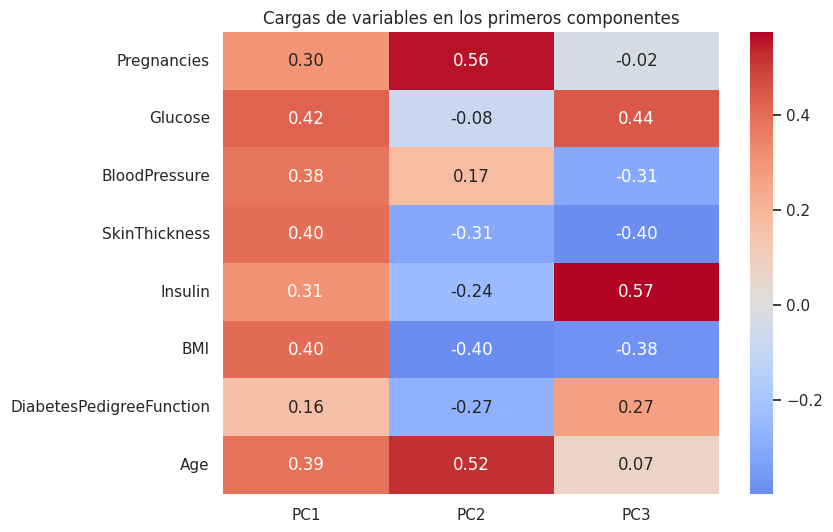

In [22]:
# ============================================================
# 13. Cargas de PCA
# ============================================================

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(numeric_vars))],
    index=numeric_vars
)

display(loadings.iloc[:, :3].round(4))

plt.figure(figsize=(8,6))
sns.heatmap(loadings.iloc[:, :3], annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Cargas de variables en los primeros componentes")
plt.show()

# 8. Clustering

Se buscan perfiles ocultos de pacientes sin usar `Outcome`. Luego se evalúa la tasa de diabetes en cada cluster.

,k,Inercia,Silhouette
0,2,4974.8598,0.1963
1,3,4335.7422,0.1950
2,4,3912.6659,0.1867
3,5,3677.0426,0.1827
4,6,3472.8027,0.1723
5,7,3299.1247,0.1221


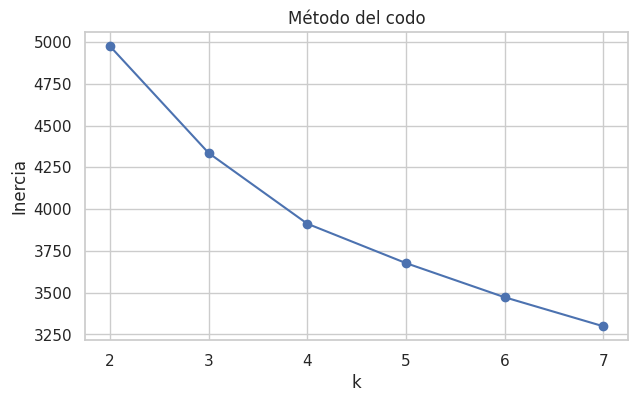

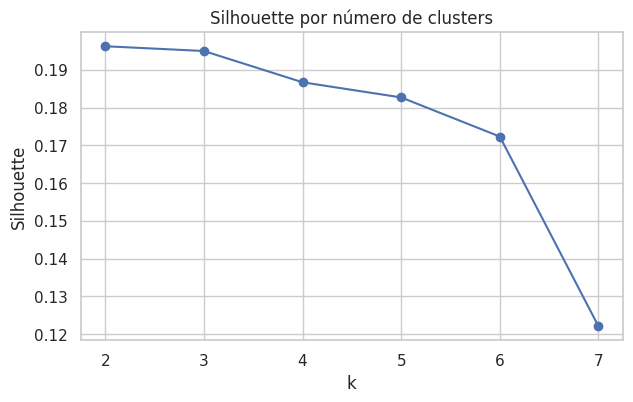

In [23]:
# ============================================================
# 14. Selección de número de clusters
# ============================================================

inertias, silhouettes = [], []
k_values = range(2, 8)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

cluster_eval = pd.DataFrame({"k": list(k_values), "Inercia": inertias, "Silhouette": silhouettes})
display(cluster_eval.round(4))

plt.figure(figsize=(7,4))
plt.plot(cluster_eval["k"], cluster_eval["Inercia"], marker="o")
plt.title("Método del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(cluster_eval["k"], cluster_eval["Silhouette"], marker="o")
plt.title("Silhouette por número de clusters")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.grid(True)
plt.show()

k seleccionado por mayor Silhouette: 2

Perfil clínico promedio por Cluster_KMeans


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Cluster_KMeans,,,,,,,,,
0,2.2210,108.0000,66.8320,26.0410,117.2360,30.0580,0.4440,26.6110,0.1750
1,5.7640,137.7950,78.9520,32.7330,168.3690,35.2880,0.5050,41.0770,0.5540


,Cluster_KMeans,Outcome,DiabetesRate
0,0,0.1755,17.5481
1,1,0.5540,55.3977


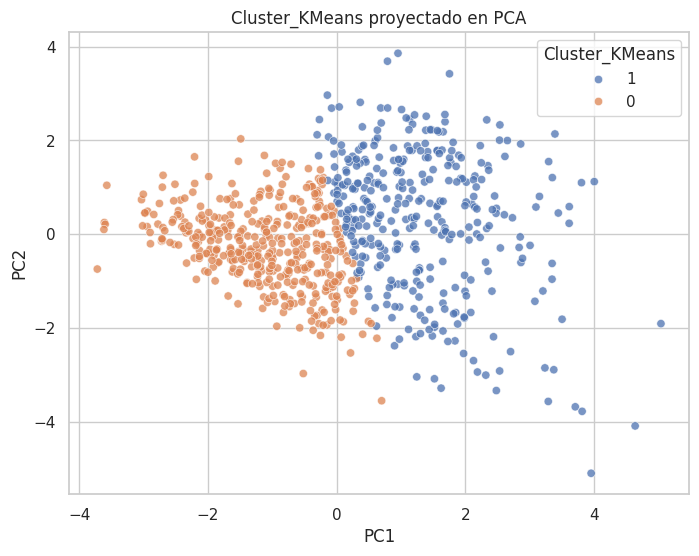

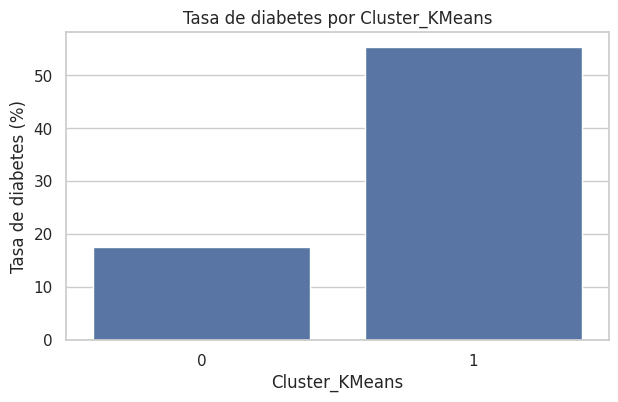


Perfil clínico promedio por Cluster_Hierarchical


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Cluster_Hierarchical,,,,,,,,,
0,4.3720,128.1170,74.9660,31.6000,152.9210,34.3880,0.4640,35.7620,0.4320
1,2.1840,101.2970,64.2590,21.2540,102.0700,26.3650,0.4970,25.2970,0.0860


,Cluster_Hierarchical,Outcome,DiabetesRate
0,0,0.4322,43.2247
1,1,0.0865,8.6486


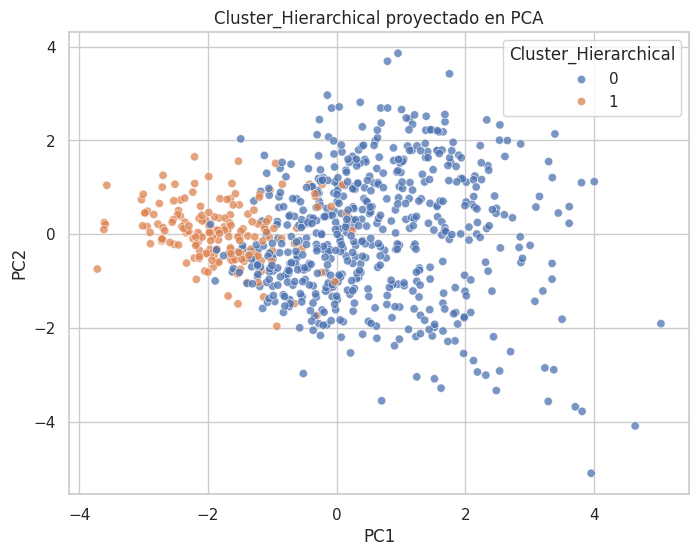

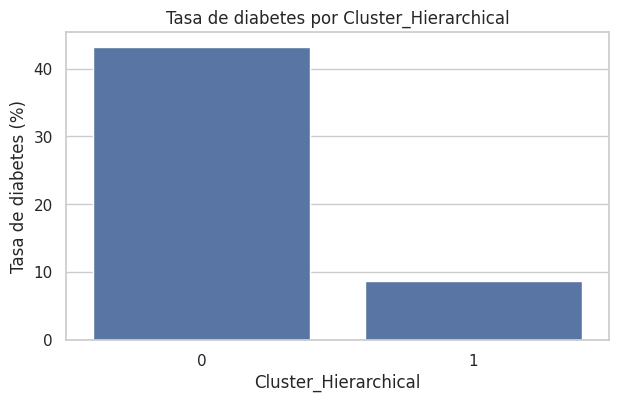

In [24]:
# ============================================================
# 15. K-Means y clustering jerárquico
# ============================================================

k_opt = int(cluster_eval.sort_values("Silhouette", ascending=False).iloc[0]["k"])
print("k seleccionado por mayor Silhouette:", k_opt)

kmeans = KMeans(n_clusters=k_opt, random_state=RANDOM_STATE, n_init=20)
df_clean["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)

hier = AgglomerativeClustering(n_clusters=k_opt)
df_clean["Cluster_Hierarchical"] = hier.fit_predict(X_scaled)

for cluster_col in ["Cluster_KMeans", "Cluster_Hierarchical"]:
    print(f"\nPerfil clínico promedio por {cluster_col}")
    display(df_clean.groupby(cluster_col)[numeric_vars + ["Outcome"]].mean().round(3))

    rate = df_clean.groupby(cluster_col)["Outcome"].mean().reset_index()
    rate["DiabetesRate"] = rate["Outcome"] * 100
    display(rate)

    plot_df = pca_df.copy()
    plot_df[cluster_col] = df_clean[cluster_col].astype(str)
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue=cluster_col, alpha=0.75)
    plt.title(f"{cluster_col} proyectado en PCA")
    plt.show()

    plt.figure(figsize=(7,4))
    sns.barplot(data=rate, x=cluster_col, y="DiabetesRate")
    plt.title(f"Tasa de diabetes por {cluster_col}")
    plt.ylabel("Tasa de diabetes (%)")
    plt.show()

# 9. SMOTE y validación cruzada

SMOTE se integra dentro del pipeline para evitar fuga de información. Se usa validación cruzada estratificada de 5 folds.

In [25]:
# ============================================================
# 16. División entrenamiento-prueba
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Distribución y_train:")
display(y_train.value_counts())
print("Distribución y_test:")
display(y_test.value_counts())

Distribución y_train:


,count
Outcome,
0,375
1,201


Distribución y_test:


,count
Outcome,
0,125
1,67


In [26]:
# ============================================================
# 17. Pipelines con SMOTE y validación cruzada
# ============================================================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

model_pipelines = {
    "Logistic Regression + SMOTE": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]),
    "Random Forest + SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, class_weight="balanced"))
    ]),
    "Gradient Boosting + SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []
for name, pipe in model_pipelines.items():
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {"Modelo": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_sd"] = scores[f"test_{metric}"].std()
    cv_rows.append(row)

cv_results_df = pd.DataFrame(cv_rows).round(4)
display(cv_results_df)

,Modelo,accuracy_mean,accuracy_sd,precision_mean,precision_sd,recall_mean,recall_sd,f1_mean,f1_sd,roc_auc_mean,roc_auc_sd
0,Logistic Regression + SMOTE,0.7396,0.0265,0.6143,0.0400,0.6918,0.0585,0.6492,0.0351,0.8240,0.0400
1,Random Forest + SMOTE,0.7465,0.0389,0.6301,0.0635,0.6765,0.0811,0.6498,0.0561,0.8006,0.0418
2,Gradient Boosting + SMOTE,0.7309,0.0431,0.6099,0.0688,0.6670,0.0736,0.6338,0.0514,0.8106,0.0421


,Modelo,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression + SMOTE,0.7656,0.6618,0.6716,0.6667,0.8381
1,Random Forest + SMOTE,0.7812,0.6582,0.7761,0.7123,0.8449
2,Gradient Boosting + SMOTE,0.7760,0.6500,0.7761,0.7075,0.8518


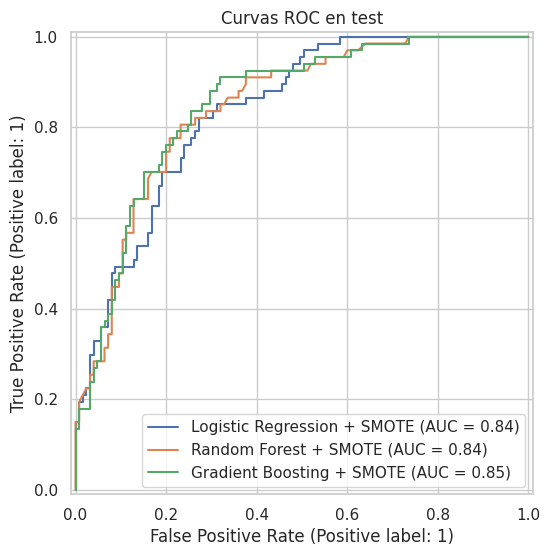

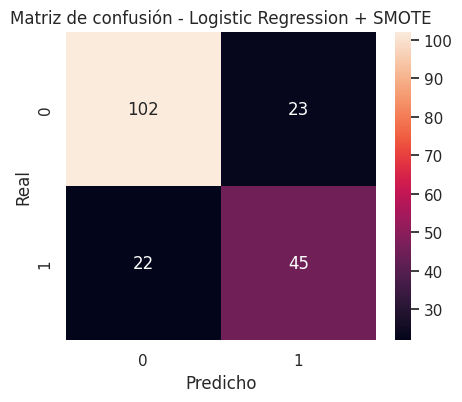


Reporte de clasificación - Logistic Regression + SMOTE
              precision    recall  f1-score   support

           0       0.82      0.82      0.82       125
           1       0.66      0.67      0.67        67

    accuracy                           0.77       192
   macro avg       0.74      0.74      0.74       192
weighted avg       0.77      0.77      0.77       192



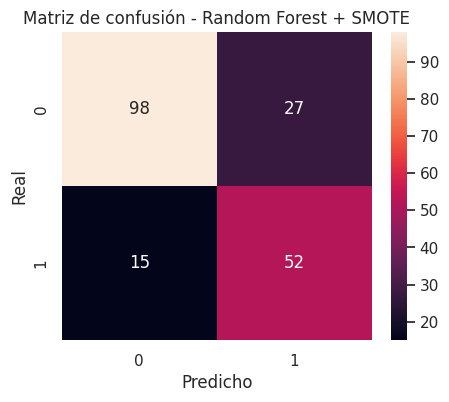


Reporte de clasificación - Random Forest + SMOTE
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       125
           1       0.66      0.78      0.71        67

    accuracy                           0.78       192
   macro avg       0.76      0.78      0.77       192
weighted avg       0.79      0.78      0.78       192



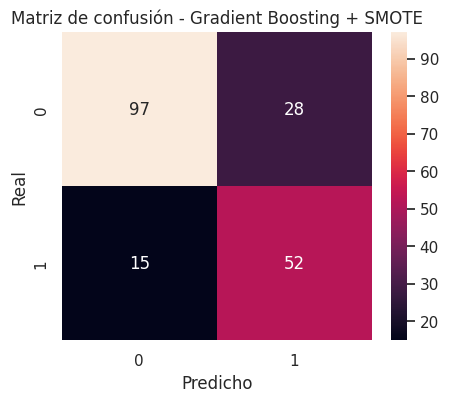


Reporte de clasificación - Gradient Boosting + SMOTE
              precision    recall  f1-score   support

           0       0.87      0.78      0.82       125
           1       0.65      0.78      0.71        67

    accuracy                           0.78       192
   macro avg       0.76      0.78      0.76       192
weighted avg       0.79      0.78      0.78       192



In [27]:
# ============================================================
# 18. Evaluación en test
# ============================================================

test_rows = []

for name, pipe in model_pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    test_rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })

test_results_df = pd.DataFrame(test_rows).round(4)
display(test_results_df)

plt.figure(figsize=(8,6))
for name, pipe in model_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=plt.gca())
plt.title("Curvas ROC en test")
plt.show()

for name, pipe in model_pipelines.items():
    pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Matriz de confusión - {name}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()
    print(f"\nReporte de clasificación - {name}")
    print(classification_report(y_test, pred))

# 10. Importancia de variables

Se calcula importancia interna de Random Forest e importancia por permutación.

,Variable,Importance_RF
1,Glucose,0.2618
5,BMI,0.1771
7,Age,0.1186
6,DiabetesPedigreeFunction,0.1120
4,Insulin,0.0936
2,BloodPressure,0.0881
3,SkinThickness,0.0827
0,Pregnancies,0.0661


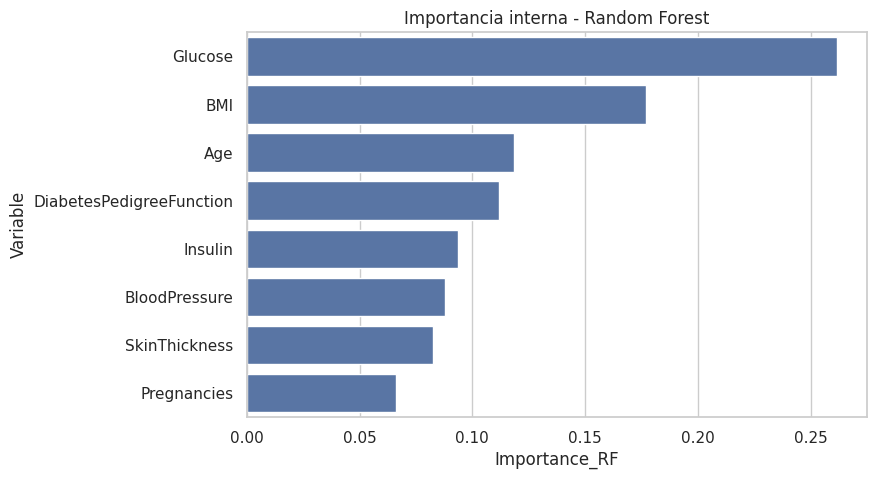

,Variable,Importance_Mean,Importance_SD
1,Glucose,0.1383,0.0316
5,BMI,0.0432,0.0186
7,Age,0.0416,0.0099
6,DiabetesPedigreeFunction,0.0170,0.0071
4,Insulin,0.0120,0.0084
0,Pregnancies,0.0043,0.0035
3,SkinThickness,0.0042,0.0055
2,BloodPressure,0.0039,0.0063


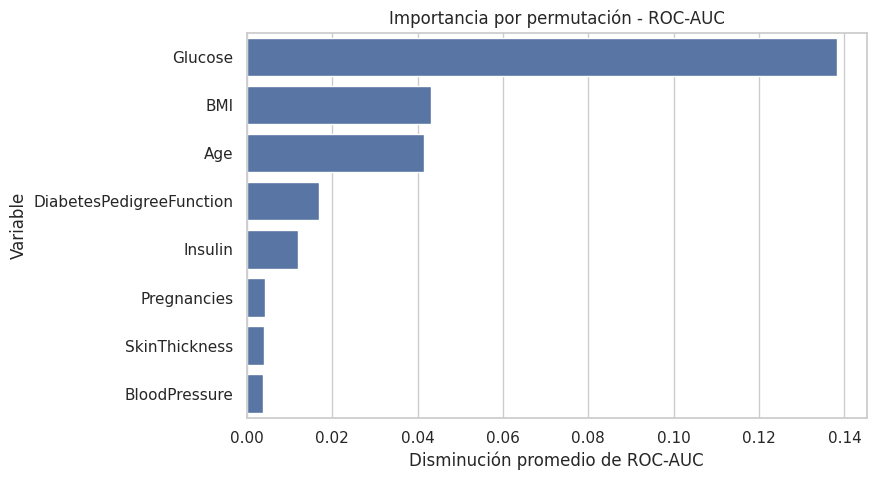

In [28]:
# ============================================================
# 19. Importancia interna y por permutación
# ============================================================

rf_pipe = model_pipelines["Random Forest + SMOTE"]
rf_model = rf_pipe.named_steps["model"]

internal_importance = pd.DataFrame({
    "Variable": numeric_vars,
    "Importance_RF": rf_model.feature_importances_
}).sort_values("Importance_RF", ascending=False)

display(internal_importance.round(4))

plt.figure(figsize=(8,5))
sns.barplot(data=internal_importance, x="Importance_RF", y="Variable")
plt.title("Importancia interna - Random Forest")
plt.show()

perm = permutation_importance(
    rf_pipe, X_test, y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="roc_auc"
)

perm_importance = pd.DataFrame({
    "Variable": numeric_vars,
    "Importance_Mean": perm.importances_mean,
    "Importance_SD": perm.importances_std
}).sort_values("Importance_Mean", ascending=False)

display(perm_importance.round(4))

plt.figure(figsize=(8,5))
sns.barplot(data=perm_importance, x="Importance_Mean", y="Variable")
plt.title("Importancia por permutación - ROC-AUC")
plt.xlabel("Disminución promedio de ROC-AUC")
plt.show()

# 11. SHAP Values

SHAP explica la contribución de cada variable a la predicción de diabetes.

- Valor SHAP positivo: incrementa la probabilidad estimada de diabetes.
- Valor SHAP negativo: reduce la probabilidad estimada de diabetes.

SHAP summary plot tipo barras


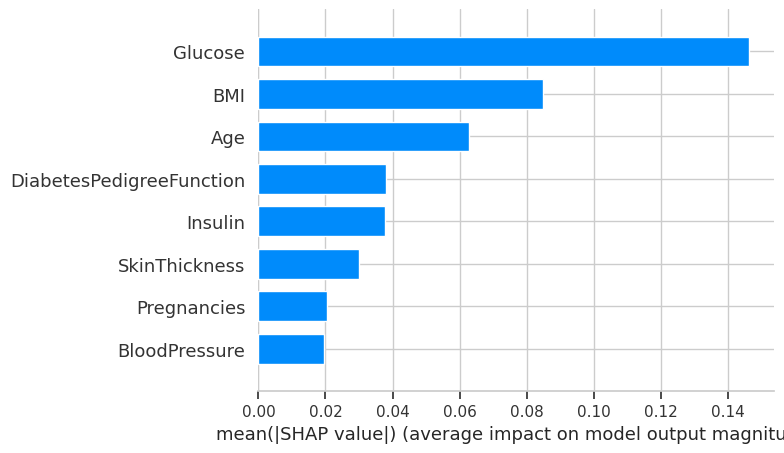

SHAP summary plot completo


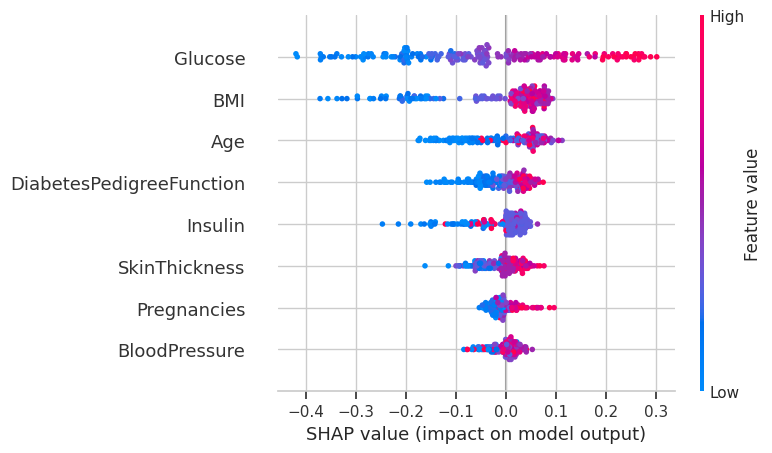

Dependence plot para Glucose


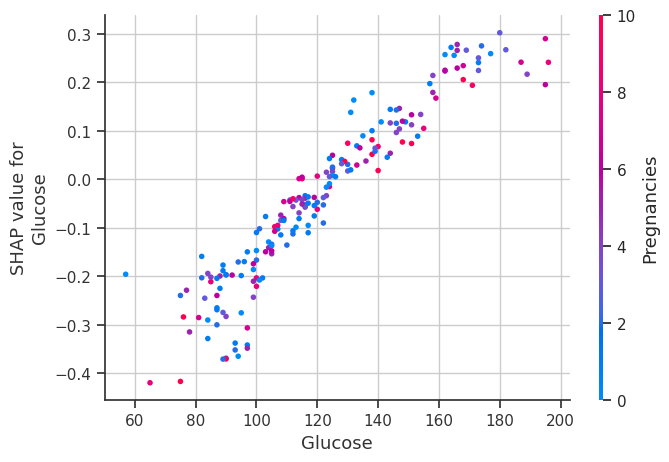

Dependence plot para BMI


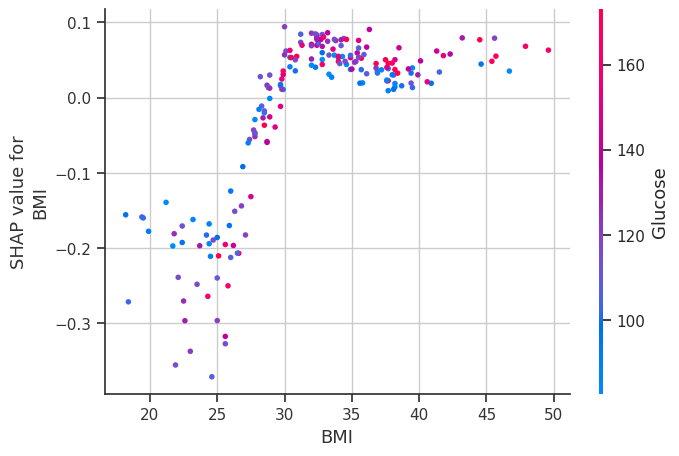

Dependence plot para Age


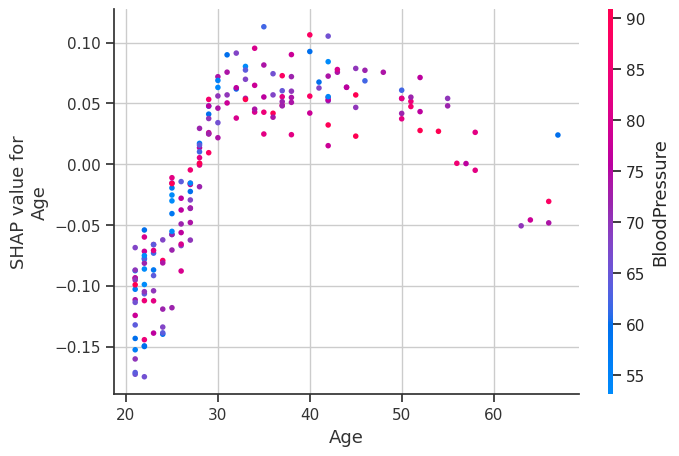

Dependence plot para DiabetesPedigreeFunction


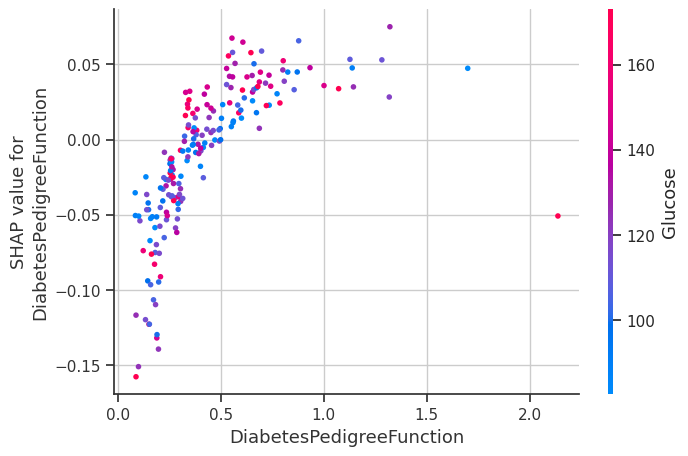

In [29]:
# ============================================================
# 20. SHAP Values
# ============================================================

if SHAP_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_STATE)
    X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

    shap_rf = RandomForestClassifier(
        n_estimators=500,
        random_state=RANDOM_STATE,
        class_weight="balanced"
    )
    shap_rf.fit(X_train_smote, y_train_smote)

    explainer = shap.TreeExplainer(shap_rf)
    shap_values = explainer.shap_values(X_test)

    if isinstance(shap_values, list):
        shap_values_positive = shap_values[1]
    else:
        shap_values_positive = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

    print("SHAP summary plot tipo barras")
    shap.summary_plot(shap_values_positive, X_test, plot_type="bar", show=True)

    print("SHAP summary plot completo")
    shap.summary_plot(shap_values_positive, X_test, show=True)

    for var in ["Glucose", "BMI", "Age", "DiabetesPedigreeFunction"]:
        print(f"Dependence plot para {var}")
        shap.dependence_plot(var, shap_values_positive, X_test, show=True)
else:
    print("SHAP no está disponible. Ejecute nuevamente la celda de instalación.")

# 12. Bootstrap clínico

Se estiman intervalos de confianza empíricos para diferencias clínicas y para el ROC-AUC del mejor modelo.

,Variable,Diferencia_observada,IC_2.5%,IC_97.5%
0,Glucose,31.4486,27.4200,35.4413
1,BMI,4.4980,3.5247,5.4871
2,Age,5.8772,4.1780,7.5461
3,Insulin,36.9095,23.3696,51.1133
4,DiabetesPedigreeFunction,0.1208,0.0713,0.1744


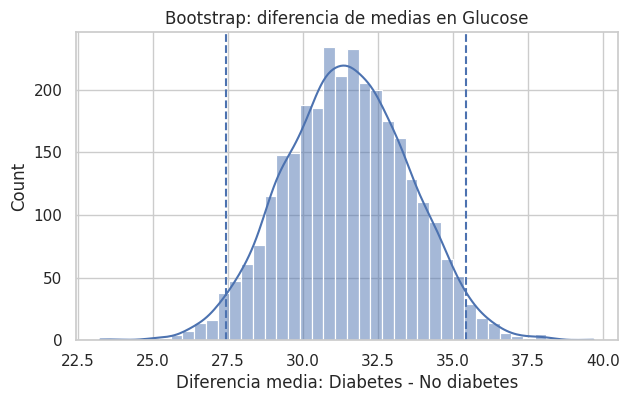

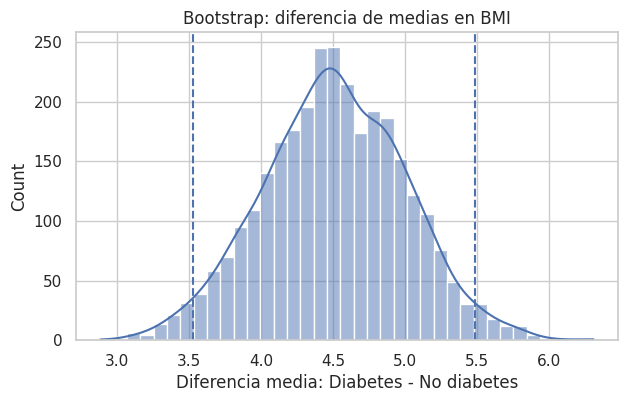

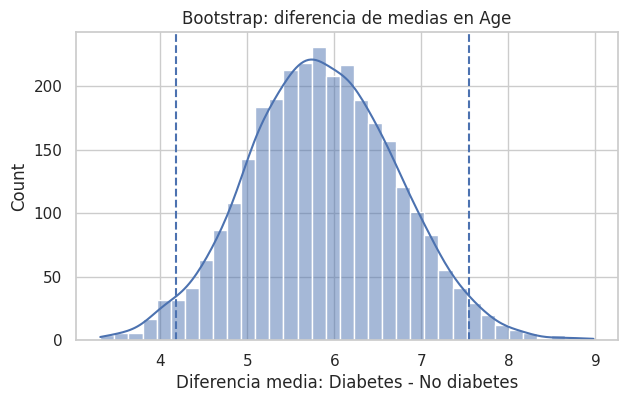

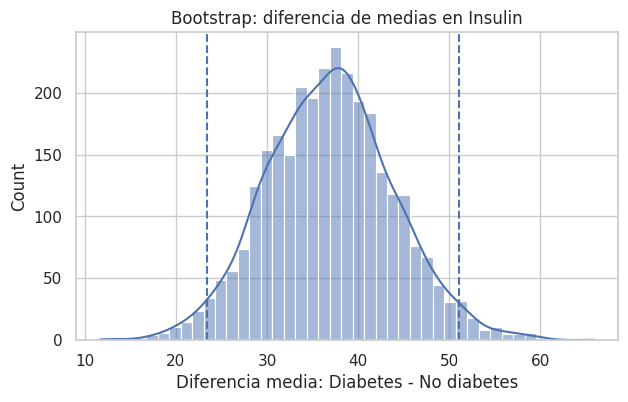

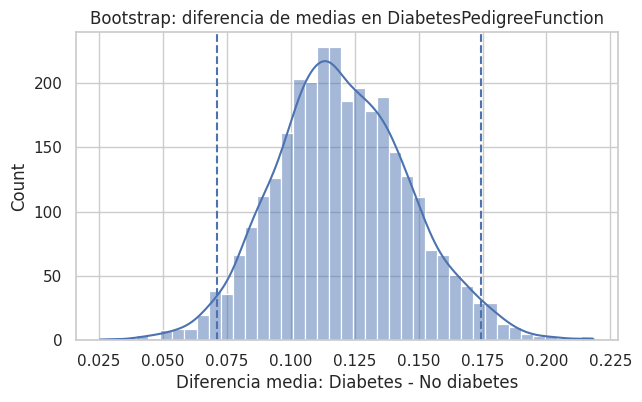

In [30]:
# ============================================================
# 21. Bootstrap para diferencias de medias
# ============================================================

def bootstrap_mean_diff(data, variable, target="Outcome", n_boot=3000, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    data0 = data.loc[data[target] == 0, variable].values
    data1 = data.loc[data[target] == 1, variable].values
    diffs = []
    for _ in range(n_boot):
        s0 = rng.choice(data0, size=len(data0), replace=True)
        s1 = rng.choice(data1, size=len(data1), replace=True)
        diffs.append(s1.mean() - s0.mean())
    diffs = np.array(diffs)
    return {
        "Variable": variable,
        "Diferencia_observada": data1.mean() - data0.mean(),
        "IC_2.5%": np.percentile(diffs, 2.5),
        "IC_97.5%": np.percentile(diffs, 97.5)
    }, diffs

boot_rows = []
boot_dist = {}
for var in ["Glucose", "BMI", "Age", "Insulin", "DiabetesPedigreeFunction"]:
    row, dist = bootstrap_mean_diff(df_clean, var)
    boot_rows.append(row)
    boot_dist[var] = dist

boot_df = pd.DataFrame(boot_rows).round(4)
display(boot_df)

for var, dist in boot_dist.items():
    plt.figure(figsize=(7,4))
    sns.histplot(dist, kde=True)
    plt.axvline(np.percentile(dist, 2.5), linestyle="--")
    plt.axvline(np.percentile(dist, 97.5), linestyle="--")
    plt.title(f"Bootstrap: diferencia de medias en {var}")
    plt.xlabel("Diferencia media: Diabetes - No diabetes")
    plt.show()

Mejor modelo según ROC-AUC: Gradient Boosting + SMOTE


,Modelo,ROC_AUC_observado,IC_2.5%,IC_97.5%
0,Gradient Boosting + SMOTE,0.8518,0.7959,0.9034


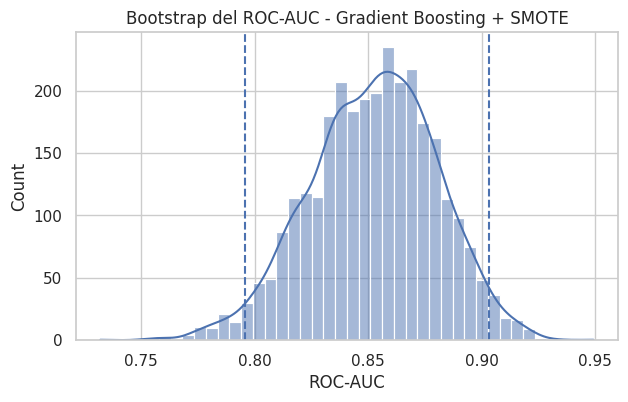

In [31]:
# ============================================================
# 22. Bootstrap del ROC-AUC
# ============================================================

best_model_name = test_results_df.sort_values("ROC_AUC", ascending=False).iloc[0]["Modelo"]
best_model = model_pipelines[best_model_name]

print("Mejor modelo según ROC-AUC:", best_model_name)

y_proba = best_model.predict_proba(X_test)[:, 1]
y_true = y_test.reset_index(drop=True).values

def bootstrap_auc(y_true, y_proba, n_boot=3000, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    aucs = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = rng.choice(np.arange(n), size=n, replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_proba[idx]))
    return np.array(aucs)

auc_dist = bootstrap_auc(y_true, y_proba)
auc_summary = pd.DataFrame({
    "Modelo": [best_model_name],
    "ROC_AUC_observado": [roc_auc_score(y_true, y_proba)],
    "IC_2.5%": [np.percentile(auc_dist, 2.5)],
    "IC_97.5%": [np.percentile(auc_dist, 97.5)]
}).round(4)

display(auc_summary)

plt.figure(figsize=(7,4))
sns.histplot(auc_dist, kde=True)
plt.axvline(np.percentile(auc_dist, 2.5), linestyle="--")
plt.axvline(np.percentile(auc_dist, 97.5), linestyle="--")
plt.title(f"Bootstrap del ROC-AUC - {best_model_name}")
plt.xlabel("ROC-AUC")
plt.show()

# 13. Regresión logística con interacciones

Modelo explicativo:

$$
\log\left(\frac{p}{1-p}\right)=
\beta_0 + \beta_1Glucose + \beta_2BMI + \beta_3Age +
\beta_4DiabetesPedigreeFunction + \beta_5(Glucose \times BMI) + \beta_6(Glucose \times Age)
$$

Este modelo evalúa si el efecto de glucosa cambia según IMC o edad.

In [32]:
# ============================================================
# 23. Regresión logística con interacciones
# ============================================================

model_interaction = smf.logit(
    "Outcome ~ Glucose + BMI + Age + DiabetesPedigreeFunction + Glucose:BMI + Glucose:Age",
    data=df_clean
).fit(disp=False)

print(model_interaction.summary())

def odds_ratios(model):
    params = model.params
    conf = model.conf_int()
    table = pd.DataFrame({
        "Coeficiente": params,
        "Odds_Ratio": np.exp(params),
        "IC_2.5%": np.exp(conf[0]),
        "IC_97.5%": np.exp(conf[1]),
        "p_value": model.pvalues
    })
    return table.round(4)

or_table = odds_ratios(model_interaction)
display(or_table)

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  768
Model:                          Logit   Df Residuals:                      761
Method:                           MLE   Df Model:                            6
Date:                Wed, 06 May 2026   Pseudo R-squ.:                  0.2695
Time:                        20:22:44   Log-Likelihood:                -362.86
converged:                       True   LL-Null:                       -496.74
Covariance Type:            nonrobust   LLR p-value:                 6.519e-55
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                  -13.6559      2.943     -4.641      0.000     -19.423      -7.889
Glucose                      0.0700      0.023      3.034      0.002       0.025       0.

,Coeficiente,Odds_Ratio,IC_2.5%,IC_97.5%,p_value
Intercept,-13.6559,0.0000,0.0000,0.0004,0.0000
Glucose,0.0700,1.0725,1.0251,1.1220,0.0024
BMI,0.1360,1.1457,0.9972,1.3164,0.0549
Age,0.1050,1.1107,1.0326,1.1946,0.0047
DiabetesPedigreeFunction,0.7902,2.2037,1.2390,3.9198,0.0072
Glucose:BMI,-0.0004,0.9996,0.9985,1.0007,0.4721
Glucose:Age,-0.0006,0.9994,0.9989,1.0000,0.0358


# 14. Perfilamiento clínico predictivo

Se simulan perfiles de pacientes para visualizar cómo cambia el riesgo estimado según glucosa, edad, IMC y riesgo hereditario.

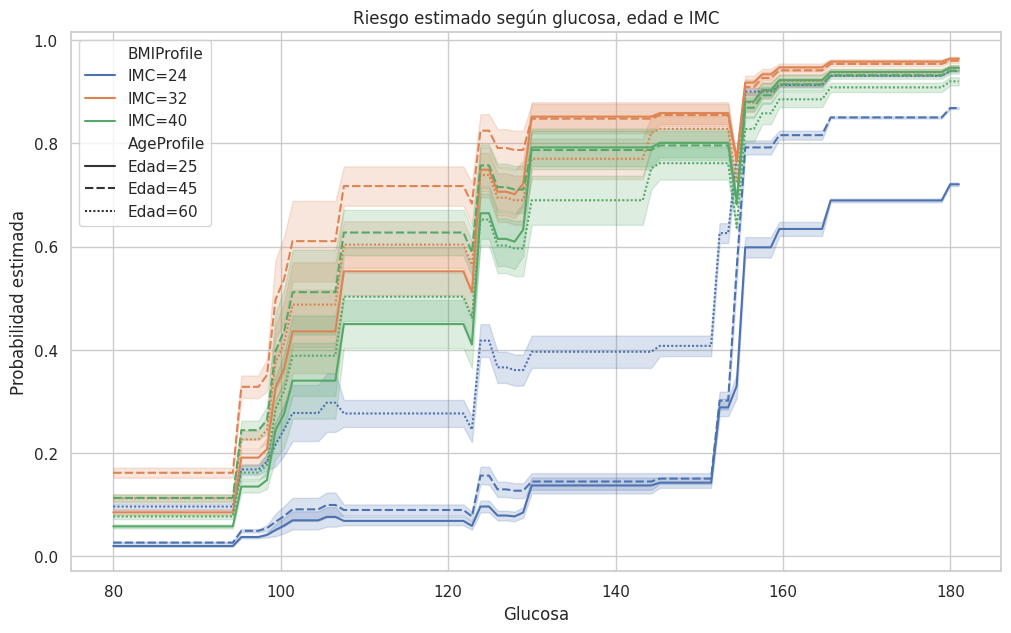

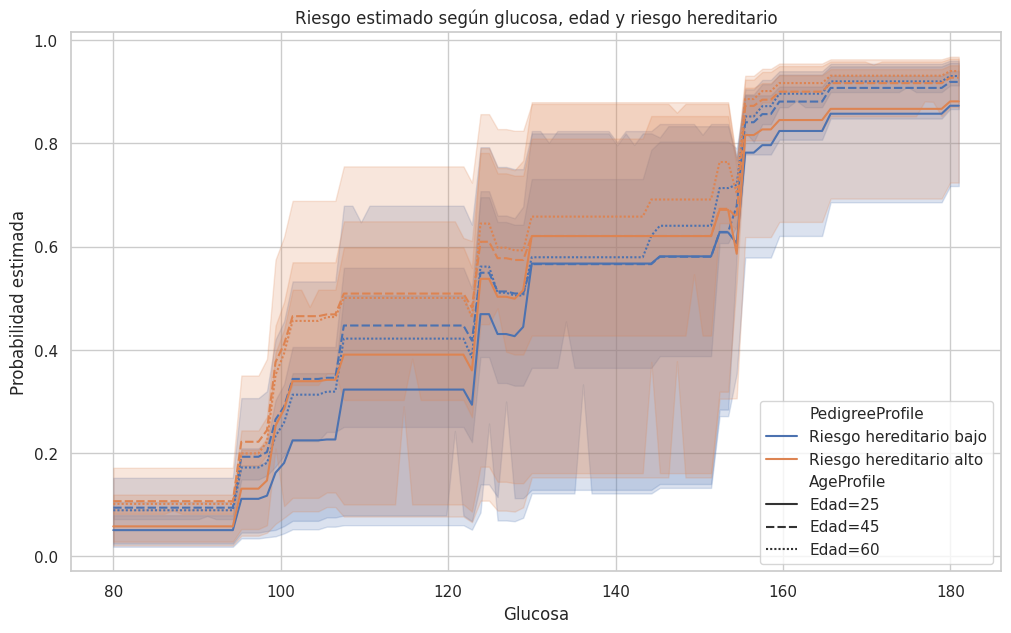

In [33]:
# ============================================================
# 24. Perfilamiento clínico predictivo
# ============================================================

glucose_range = np.linspace(df_clean["Glucose"].quantile(0.05), df_clean["Glucose"].quantile(0.95), 100)
profiles = []

for age in [25, 45, 60]:
    for bmi in [24, 32, 40]:
        for pedigree in [
            df_clean["DiabetesPedigreeFunction"].quantile(0.25),
            df_clean["DiabetesPedigreeFunction"].quantile(0.75)
        ]:
            for glucose in glucose_range:
                profiles.append({
                    "Pregnancies": df_clean["Pregnancies"].median(),
                    "Glucose": glucose,
                    "BloodPressure": df_clean["BloodPressure"].median(),
                    "SkinThickness": df_clean["SkinThickness"].median(),
                    "Insulin": df_clean["Insulin"].median(),
                    "BMI": bmi,
                    "DiabetesPedigreeFunction": pedigree,
                    "Age": age
                })

profiles_df = pd.DataFrame(profiles)
profiles_df["Risk"] = best_model.predict_proba(profiles_df[numeric_vars])[:, 1]
profiles_df["AgeProfile"] = "Edad=" + profiles_df["Age"].astype(str)
profiles_df["BMIProfile"] = "IMC=" + profiles_df["BMI"].astype(str)
profiles_df["PedigreeProfile"] = np.where(
    profiles_df["DiabetesPedigreeFunction"] <= df_clean["DiabetesPedigreeFunction"].median(),
    "Riesgo hereditario bajo",
    "Riesgo hereditario alto"
)

plt.figure(figsize=(12,7))
sns.lineplot(data=profiles_df, x="Glucose", y="Risk", hue="BMIProfile", style="AgeProfile")
plt.title("Riesgo estimado según glucosa, edad e IMC")
plt.ylabel("Probabilidad estimada")
plt.xlabel("Glucosa")
plt.show()

plt.figure(figsize=(12,7))
sns.lineplot(data=profiles_df, x="Glucose", y="Risk", hue="PedigreeProfile", style="AgeProfile")
plt.title("Riesgo estimado según glucosa, edad y riesgo hereditario")
plt.ylabel("Probabilidad estimada")
plt.xlabel("Glucosa")
plt.show()

# 15. Interpretación

## Hallazgo descriptivo

Los pacientes con diabetes tienden a presentar mayores valores de glucosa, IMC, edad y función hereditaria.

## Insight superficial

La glucosa es una variable dominante para explicar el diagnóstico de diabetes.

## Insight oculto

El riesgo de diabetes no debe interpretarse como efecto de una sola variable aislada. El riesgo emerge de la combinación de variables metabólicas y demográficas.

Dos pacientes con glucosa similar pueden presentar riesgos distintos si difieren en:

- IMC;
- edad;
- insulina;
- embarazos;
- función hereditaria.

## Aporte del PCA

El PCA permite observar la estructura multivariada de los pacientes y visualizar si existen diferencias parciales entre pacientes con y sin diabetes.

## Aporte del clustering

El clustering encuentra grupos ocultos de pacientes sin usar el diagnóstico. Si algunos clusters tienen mayor tasa de diabetes, estos grupos representan perfiles clínicos latentes de riesgo.

## Aporte de SMOTE

SMOTE mejora el aprendizaje de la clase positiva dentro de validación cruzada y reduce el sesgo hacia la clase mayoritaria.

## Aporte de SHAP

SHAP permite explicar las predicciones del modelo mostrando qué variables aumentan o reducen el riesgo estimado de diabetes.

## Aporte del bootstrap clínico

El bootstrap ofrece intervalos de confianza empíricos para diferencias clínicas y para el ROC-AUC, incorporando incertidumbre estadística.

## Conclusión general

El principal insight oculto es que la diabetes debe analizarse como un fenómeno multivariado: la glucosa es fundamental, pero su interpretación mejora al combinarla con IMC, edad, insulina y función hereditaria.

In [34]:
# ============================================================
# 25. Exportación de resultados
# ============================================================

df_clean.to_csv("diabetes_limpia_experta.csv", index=False)
cv_results_df.to_csv("resultados_validacion_cruzada.csv", index=False)
test_results_df.to_csv("resultados_modelos_prueba.csv", index=False)
perm_importance.to_csv("importancia_variables_permutacion.csv", index=False)
boot_df.to_csv("bootstrap_diferencias_clinicas.csv", index=False)

print("Archivos exportados:")
print("- diabetes_limpia_experta.csv")
print("- resultados_validacion_cruzada.csv")
print("- resultados_modelos_prueba.csv")
print("- importancia_variables_permutacion.csv")
print("- bootstrap_diferencias_clinicas.csv")

Archivos exportados:
- diabetes_limpia_experta.csv
- resultados_validacion_cruzada.csv
- resultados_modelos_prueba.csv
- importancia_variables_permutacion.csv
- bootstrap_diferencias_clinicas.csv
